In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [30]:
df = pd.read_csv("StudentPerformanceFactors.csv")

In [31]:
df.shape

(6607, 20)

In [32]:
df.head(20)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


In [44]:
num_cols = df.select_dtypes(include='number').columns

print("There are", len(num_cols) ," number of columns")
print("The Numerical Columns are: ", list(num_cols))


There are 7  number of columns
The Numerical Columns are:  ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


In [51]:
calculation = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Mode": df[num_cols].mode().iloc[0],
    "Variance": df[num_cols].var(),
    "Std Dev": df[num_cols].std(),
    "IQR": df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
})

calculation

,Mean,Median,Mode,Variance,Std Dev,IQR
Hours_Studied,19.975329,20.0,20,35.887221,5.990594,8.0
Attendance,79.977448,80.0,67,133.344178,11.547475,20.0
Sleep_Hours,7.029060,7.0,7,2.155377,1.468120,2.0
Previous_Scores,75.070531,75.0,66,207.353789,14.399784,25.0
Tutoring_Sessions,1.493719,1.0,1,1.514304,1.230570,1.0
Physical_Activity,2.967610,3.0,3,1.063438,1.031231,2.0
Exam_Score,67.235659,67.0,68,15.135646,3.890456,4.0


<Figure size 640x480 with 0 Axes>

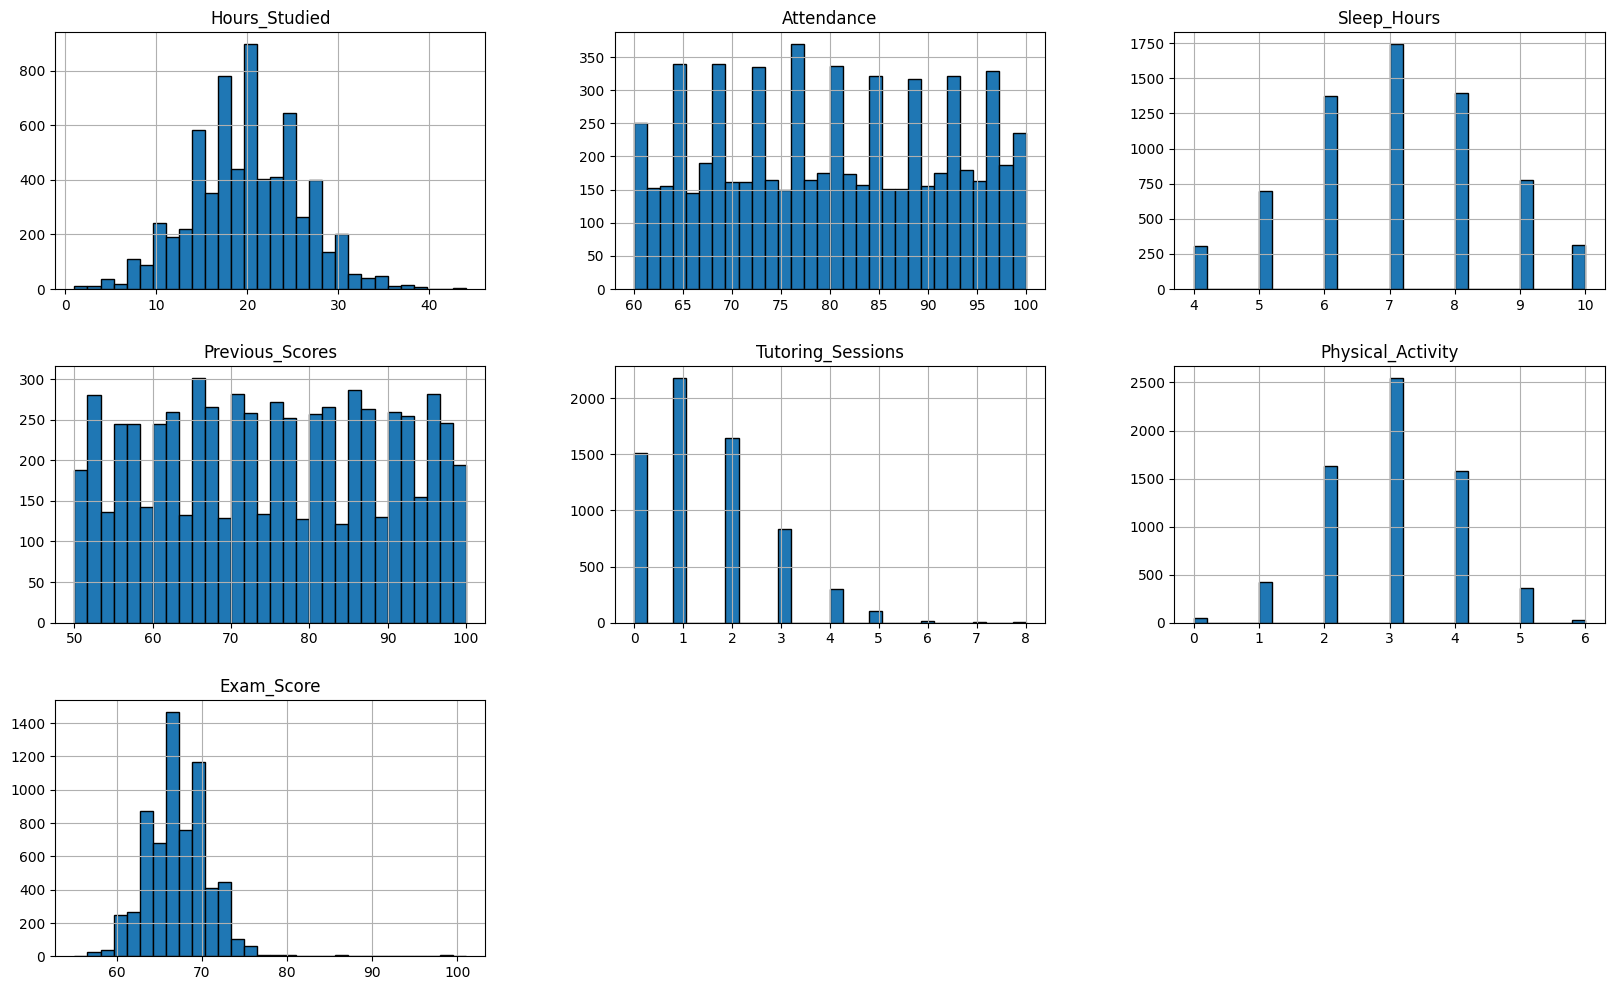

In [82]:
plt.figure()

df[num_cols].hist(bins =30,edgecolor = 'black',figsize=(20,12))

plt.show()



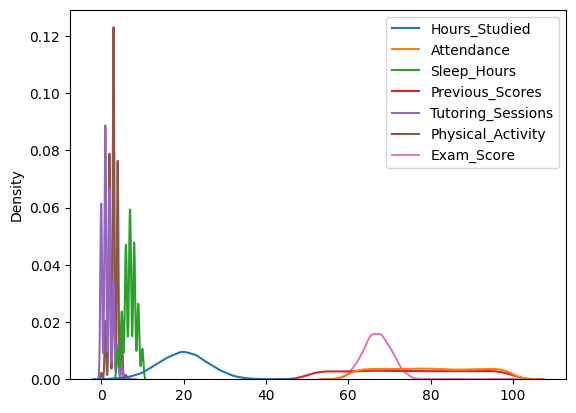

In [83]:
sns.kdeplot(df[num_cols])
plt.show()

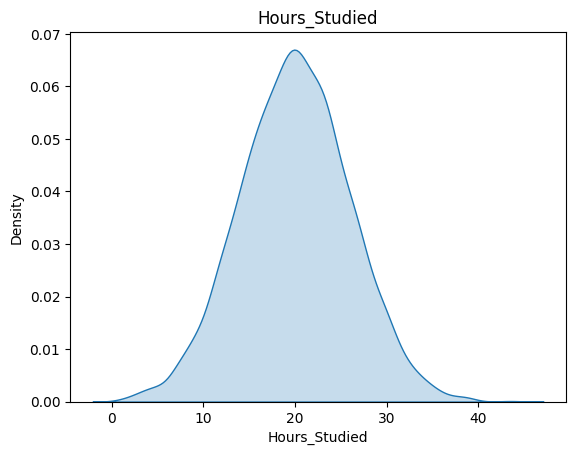

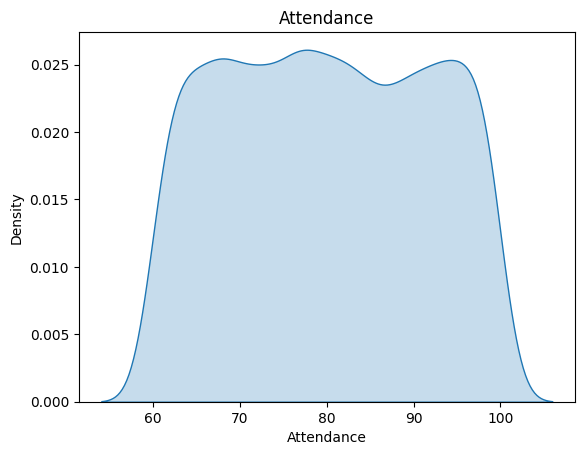

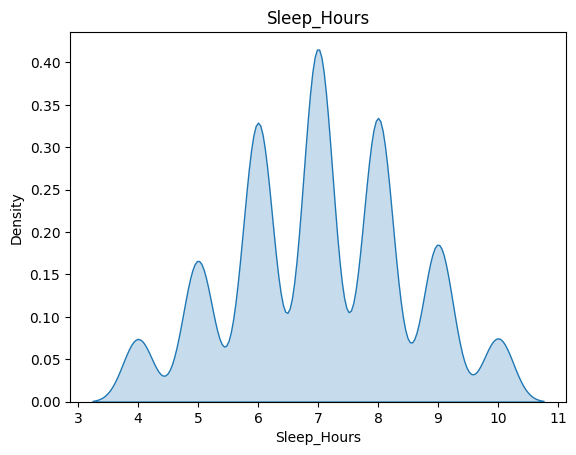

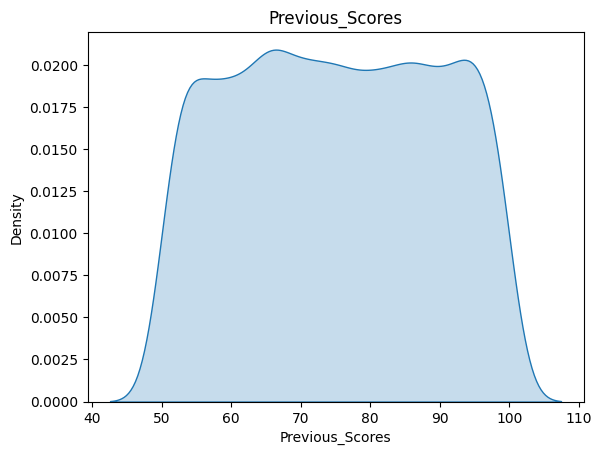

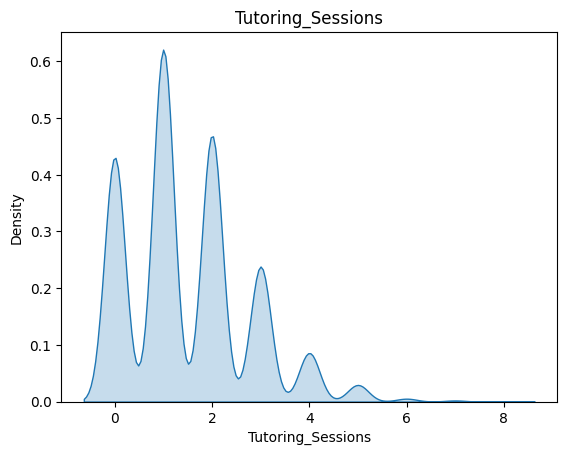

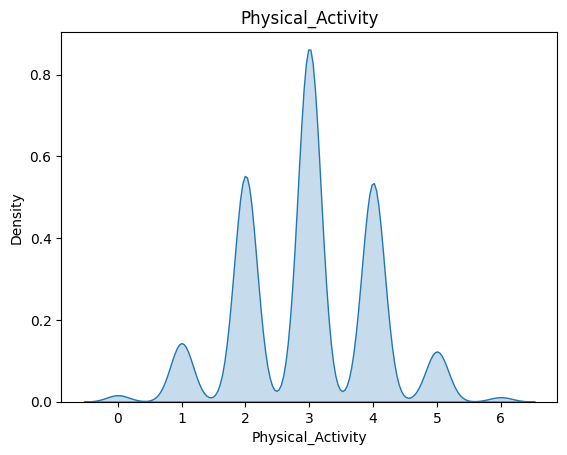

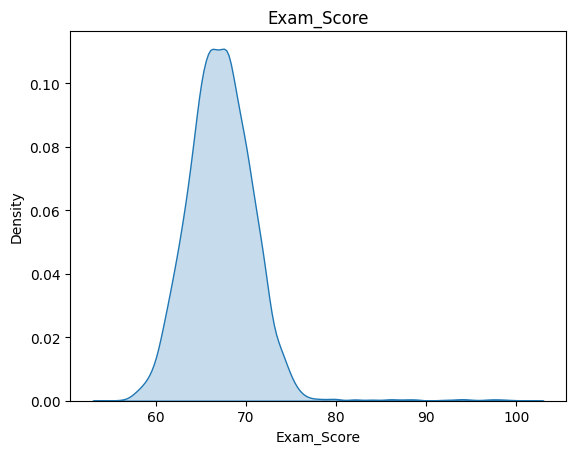

In [86]:
for col in num_cols:
    sns.kdeplot(df[col], fill=True)
    plt.title(col)
    plt.show()

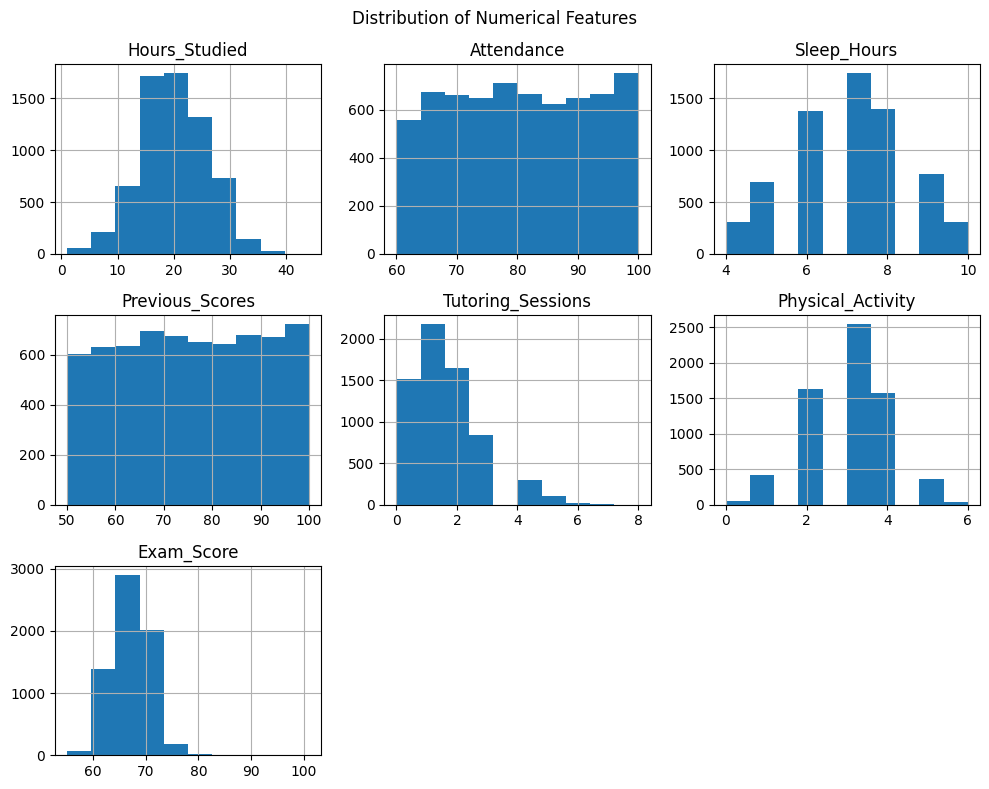

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].hist(figsize=(10,8))

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

In [ ]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

outliers = ((df[num_cols] < (Q1 - 1.5*IQR)) | (df[num_cols] > (Q3 + 1.5*IQR)))

outliers.sum()

Hours_Studied         43
Attendance             0
Sleep_Hours            0
Previous_Scores        0
Tutoring_Sessions    430
Physical_Activity      0
Exam_Score           104
dtype: int64

In [ ]:
for col in cat_cols:
    print(df[col].value_counts())

NameError: name 'cat_cols' is not defined

In [ ]:
for col in cat_cols:
    df[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(col)
    plt.ylabel("")
    plt.show()

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

In [ ]:
for col in cat_cols:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

In [ ]:
sns.pairplot(df[num_cols])
plt.show()

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()